### First time using the Met Office Site Archive?
If this is your first time using the Met Office Site Archive you may need to install it into the PyEarthTools project.
Using your terminal navigate to the `PyEarthTools/packages` folder and run the following command:

`pip install -e met_office_site_archive`

# Using the Met Office Site Archive

This notebook demonstrates how to use the PyEarthTools Met Office site archive. <br>
Place the Met Office .pyearthtoolsconfig file in your home directory so PyEarthTools can automatically detect and register datasets on disk. <br>
So far we have configured some demo data with a subset of time and variables for the following datasets:
* ERA5 low resolution (WeatherBench) data. 
* Met Office Global (2018)
* Met Office UKV (2018)

This notebook will demonstrate how to load PyEarthTools and load data from those datasets with minimal (low-code) approaches. 

## Project setup

#### Imports
If you are in the Met Office organisation you should place the `.pyearthtoolsconfig` file in your home directory as this is read during the `import site_archive_met_office` step and will be used to import the example datasets on disc for you to use. 

In [1]:
import pyearthtools
from pyearthtools import data, pipeline

import site_archive_met_office

ROOT_DIRECTORIES: {'ERA5lowres': '/data/users/dscop/weatherbench/5.625deg/', 'MOGLOBAL': '/data/users/dscop/pyearthtools_data/mo_global/', 'MOUKV': '/data/users/dscop/pyearthtools_data/mo_ukv/'}


#### Check root directories
Use the `.get_root_directories()` method to check what datasets the PyEarthTools met_office_site has registered. 

In [2]:
print(site_archive_met_office.get_root_directories())

{'ERA5lowres': '/data/users/dscop/weatherbench/5.625deg/', 'MOGLOBAL': '/data/users/dscop/pyearthtools_data/mo_global/', 'MOUKV': '/data/users/dscop/pyearthtools_data/mo_ukv/'}


#### Manually update dataset locations
You can add paths for the datasets you wish to work with manually using the `.set_root_directory` method.
* The dataset key needs to exist in the ROOT_DIRECTORIES dictionary as it will require a data accessor file.
* This is useful if you have data stored in a different location.

In [3]:
# site_archive_met_office.set_root_directory("ROOT_Key", "/path/to/data/")

# Print the updated ROOT_DIRECTORIES
print(site_archive_met_office.get_root_directories())

{'ERA5lowres': '/data/users/dscop/weatherbench/5.625deg/', 'MOGLOBAL': '/data/users/dscop/pyearthtools_data/mo_global/', 'MOUKV': '/data/users/dscop/pyearthtools_data/mo_ukv/'}


#### Parameters for this notebook

In [4]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

vmin = 220
vmax = 320
cmap = 'coolwarm'
figsize = (16,8)

## Working with ERA5 low resolution (WeatherBench) data
This technique can be used to quickly create a dataset object. <br>
Pass an array of the variables you wish to work with to the dataset archive.

In [5]:
era5 = pyearthtools.data.archive.ERA5lowres(['2m_temperature', 'u', 'v'])
era5

ERA5lowres
	Description                    ECWMF ReAnalysis v5
		 range                          '1970-current'
		 Documentation                  'https://confluence.ecmwf.int/display/CKB/ERA5%3A+data+documentation'


	Initialisation                 
		 level_value                    None
		 variables                      ['2m_temperature', 'u', 'v']
	Transforms                     
		 StandardCoordinateNames        {'latitude': "['lat', 'Latitude', 'yt_ocean', 'yt']", 'longitude': "['lon', 'Longitude', 'xt_ocean', 'xt']", 'replacement_dictionary': 'None', 'time': "['Time']"}

Using the dataset object index on a date of interest to select the data for that date. 

In [6]:
doi = '2015-01-01T00'  
era5_data = era5[doi]
era5_data

<xarray.Dataset> Size: 222kB
Dimensions:    (latitude: 32, longitude: 64, time: 1, level: 13)
Coordinates:
  * latitude   (latitude) float64 256B -87.19 -81.56 -75.94 ... 81.56 87.19
  * longitude  (longitude) float64 512B 0.0 5.625 11.25 ... 343.1 348.8 354.4
  * time       (time) datetime64[ns] 8B 2015-01-01
  * level      (level) int32 52B 50 100 150 200 250 300 ... 600 700 850 925 1000
Data variables:
    t2m        (time, latitude, longitude) float32 8kB dask.array<chunksize=(1, 32, 64), meta=np.ndarray>
    u          (time, level, latitude, longitude) float32 106kB dask.array<chunksize=(1, 8, 19, 39), meta=np.ndarray>
    v          (time, level, latitude, longitude) float32 106kB dask.array<chunksize=(1, 8, 19, 39), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6

Let's plot the data to verify our process worked. 

Text(0.5, 1.0, '2m Temperature (ERA5): 2015-01-01T00')

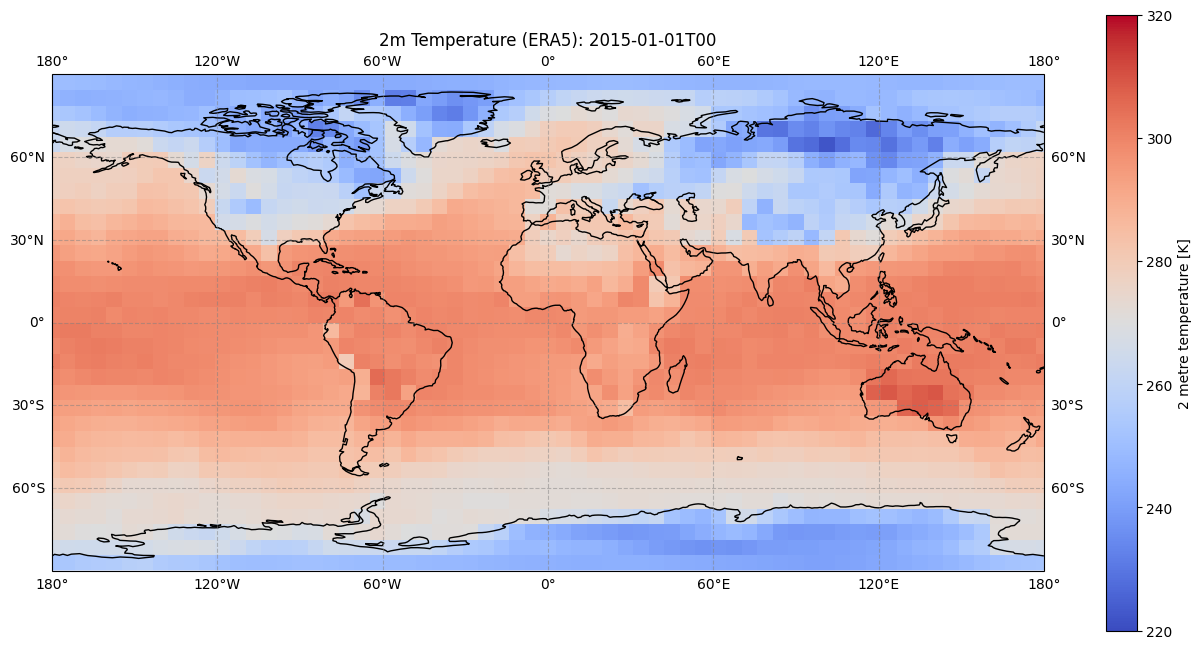

In [7]:
projection = ccrs.PlateCarree()  

fig1 = plt.figure(figsize=figsize)                              # Set up a figure
ax1 = fig1.add_subplot(1,1,1,projection=projection)             # Add a subplot with PlateCarree projection

# Add coastlines and gridlines to the map
ax1.coastlines()                                                
ax1.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)

era5_data.t2m.plot(cmap=cmap, vmin=vmin, vmax=vmax, ax=ax1)     # Add the PyEarthTools ERA5 2m temperature data using the PyEarthTools .plot() method.
ax1.set_title(f"2m Temperature (ERA5): {doi}")                          # Add your title  

## Working with Met Office UKV data
This technique can be used to quickly create a dataset object. <br>
Pass an array of the variables you wish to work with to the dataset archive.

In [8]:
moukv = pyearthtools.data.archive.MOUKV(['2m_temperature', 'u', 'v'])
moukv

MOUKV
	Description                    Met Office UKV (subset)
		 range                          '2018'
		 Documentation                  'https://www.metoffice.gov.uk/binaries/content/assets/metofficegovuk/pdf/data/ukv_model_data_sheet_2019.pdf'


	Initialisation                 
		 level_value                    None
		 variables                      ['2m_temperature', 'u', 'v']
	Transforms                     
		 StandardCoordinateNames        {'latitude': "['lat', 'Latitude', 'yt_ocean', 'yt']", 'longitude': "['lon', 'Longitude', 'xt_ocean', 'xt']", 'replacement_dictionary': 'None', 'time': "['Time']"}
		 Rename                         {'names': {'grid_latitude': "'latitude'", 'grid_longitude': "'longitude'"}}

Using the dataset object index on a date of interest to select the data for that date. 

In [9]:
doi = '2018-06-12T03'
moukv_data = moukv[doi]
moukv_data

<xarray.Dataset> Size: 14MB
Dimensions:                      (time: 1, latitude: 810, longitude: 621,
                                  grid_latitude_0: 811, grid_longitude_0: 621)
Coordinates:
  * latitude                     (latitude) float32 3kB -3.771 -3.757 ... 7.151
  * longitude                    (longitude) float64 5kB 354.9 354.9 ... 363.3
    forecast_period              timedelta64[ns] 8B ...
    forecast_reference_time      datetime64[ns] 8B ...
  * time                         (time) datetime64[ns] 8B 2018-06-12T03:00:00
    height                       float64 8B ...
    forecast_period_0            timedelta64[ns] 8B ...
    time_0                       datetime64[ns] 8B ...
  * grid_latitude_0              (grid_latitude_0) float32 3kB -3.777 ... 7.158
  * grid_longitude_0             (grid_longitude_0) float64 5kB 354.9 ... 363.3
    height_0                     float64 8B ...
Data variables:
    air_pressure_at_sea_level    (time, latitude, longitude) float32 2MB dask.array<chunksize=(1, 810, 621), meta=np.ndarray>
    rotated_latitude_longitude   (time) int32 4B -2147483647
    air_temperature              (time, latitude, longitude) float32 2MB dask.array<chunksize=(1, 810, 621), meta=np.ndarray>
    specific_humidity            (time, latitude, longitude) float32 2MB dask.array<chunksize=(1, 810, 621), meta=np.ndarray>
    surface_altitude             (time, latitude, longitude) float32 2MB dask.array<chunksize=(1, 810, 621), meta=np.ndarray>
    toa_outgoing_shortwave_flux  (time, latitude, longitude) float32 2MB dask.array<chunksize=(1, 810, 621), meta=np.ndarray>
    x_wind                       (time, grid_latitude_0, grid_longitude_0) float32 2MB dask.array<chunksize=(1, 811, 621), meta=np.ndarray>
    y_wind                       (time, grid_latitude_0, grid_longitude_0) float32 2MB dask.array<chunksize=(1, 811, 621), meta=np.ndarray>
Attributes:
    source:       Data from Met Office Unified Model
    um_version:   10.8
    Conventions:  CF-1.7

In [10]:
# Values to plot UKV as a Rotated Pole projection

grid_north_pole_latitude = moukv_data.rotated_latitude_longitude.grid_north_pole_latitude
grid_north_pole_longitude = moukv_data.rotated_latitude_longitude.grid_north_pole_longitude

lon_min = float(moukv_data.air_temperature.longitude.min())
lon_max = float(moukv_data.air_temperature.longitude.max())
lat_min = float(moukv_data.air_temperature.latitude.min())
lat_max = float(moukv_data.air_temperature.latitude.max())

Let's plot the data to verify our process worked. 

Text(0.5, 1.0, 'Air Temperature (MOUKV): 2018-06-12T03')

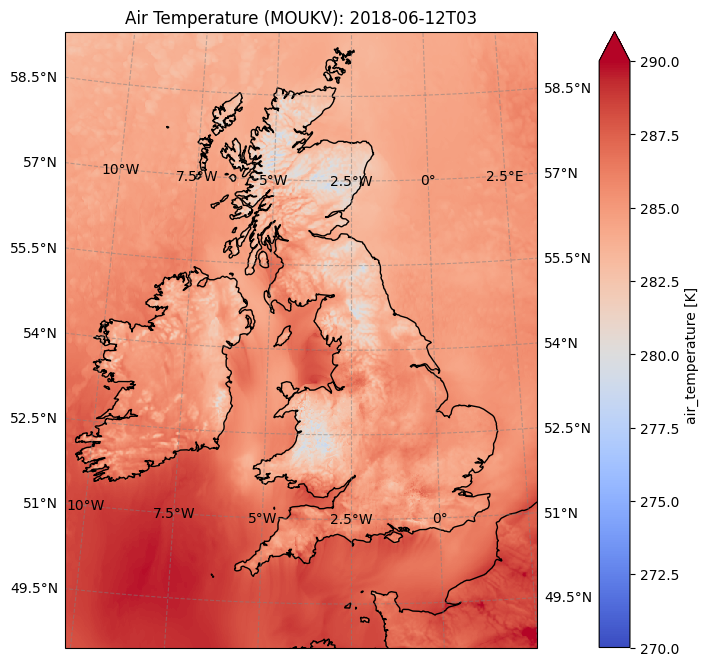

In [11]:
projection = ccrs.RotatedPole(pole_longitude=grid_north_pole_longitude, pole_latitude=grid_north_pole_latitude)

fig1 = plt.figure(figsize=figsize)                                      # Set up a figure
ax1 = fig1.add_subplot(1,1,1,projection=projection)                     # Add a subplot with Rotated Pole projection
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=projection)    # Use the min/max lat/lon and projection for the extents and crs.

# Add Coastlines and gridlines to the map
ax1.coastlines() 
ax1.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)

# Plot the MOUKV data using the PyEarthTools .plot() method and RotatedPole projection
moukv_data.air_temperature.plot(cmap=cmap, vmin=270, vmax=290, ax=ax1, transform=projection)
ax1.set_title(f"Air Temperature (MOUKV): {doi}")                          


## Working with Met Office Global data
This technique can be used to quickly create a dataset object. <br>
Pass an array of the variables you wish to work with to the dataset archive.

In [12]:
moglobal = pyearthtools.data.archive.MOGLOBAL(['2m_temperature', 'u', 'v'])
moglobal

MOGLOBAL
	Description                    Met Office Global (subset)
		 range                          '2018'
		 Documentation                  'https://www.metoffice.gov.uk/binaries/content/assets/metofficegovuk/pdf/data/global-nwp-asdi-datasheet.pdf'


	Initialisation                 
		 level_value                    None
		 variables                      ['2m_temperature', 'u', 'v']
	Transforms                     
		 StandardCoordinateNames        {'latitude': "['lat', 'Latitude', 'yt_ocean', 'yt']", 'longitude': "['lon', 'Longitude', 'xt_ocean', 'xt']", 'replacement_dictionary': 'None', 'time': "['Time']"}

Using the dataset object index on a date of interest to select the data for that date. 

In [13]:
doi = '2018-09-02T00'
moglobal_data = moglobal[doi]
moglobal_data

Matching files: [PosixPath('/data/users/dscop/pyearthtools_data/mo_global/prods_op_gl-mn_20180902_00_000.calc.nc')]


<xarray.Dataset> Size: 177MB
Dimensions:                    (time: 1, latitude: 1920, longitude: 2560,
                                bnds: 2, latitude_0: 1921, longitude_0: 2560)
Coordinates:
  * latitude                   (latitude) float32 8kB -89.95 -89.86 ... 89.95
  * longitude                  (longitude) float32 10kB 0.07031 0.2109 ... 359.9
    forecast_period            timedelta64[ns] 8B ...
    forecast_reference_time    datetime64[ns] 8B ...
  * time                       (time) datetime64[ns] 8B 2018-09-02
    height                     float64 8B ...
    forecast_period_0          timedelta64[ns] 8B ...
    time_0                     datetime64[ns] 8B ...
  * latitude_0                 (latitude_0) float32 8kB -90.0 -89.91 ... 90.0
  * longitude_0                (longitude_0) float32 10kB 0.0 0.1406 ... 359.9
    height_0                   float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    air_pressure_at_sea_level  (time, latitude, longitude) float32 20MB dask.array<chunksize=(1, 1920, 2560), meta=np.ndarray>
    latitude_longitude         (time) int32 4B -2147483647
    air_temperature            (time, latitude, longitude) float32 20MB dask.array<chunksize=(1, 1920, 2560), meta=np.ndarray>
    air_temperature_0          (time, latitude, longitude) float32 20MB dask.array<chunksize=(1, 1920, 2560), meta=np.ndarray>
    forecast_period_0_bnds     (time, bnds) float64 16B dask.array<chunksize=(1, 2), meta=np.ndarray>
    time_0_bnds                (time, bnds) datetime64[ns] 16B dask.array<chunksize=(1, 2), meta=np.ndarray>
    air_temperature_1          (time, latitude, longitude) float32 20MB dask.array<chunksize=(1, 1920, 2560), meta=np.ndarray>
    land_binary_mask           (time, latitude, longitude) int32 20MB dask.array<chunksize=(1, 1920, 2560), meta=np.ndarray>
    specific_humidity          (time, latitude, longitude) float32 20MB dask.array<chunksize=(1, 1920, 2560), meta=np.ndarray>
    surface_altitude           (time, latitude, longitude) float32 20MB dask.array<chunksize=(1, 1920, 2560), meta=np.ndarray>
    x_wind                     (time, latitude_0, longitude_0) float32 20MB dask.array<chunksize=(1, 1921, 2560), meta=np.ndarray>
    y_wind                     (time, latitude_0, longitude_0) float32 20MB dask.array<chunksize=(1, 1921, 2560), meta=np.ndarray>
Attributes:
    source:       Data from Met Office Unified Model
    um_version:   10.8
    Conventions:  CF-1.7

Let's plot the data to verify our process worked. 

Text(0.5, 1.0, 'Air Temperature (MOGLOBAL): 2018-09-02T00 ')

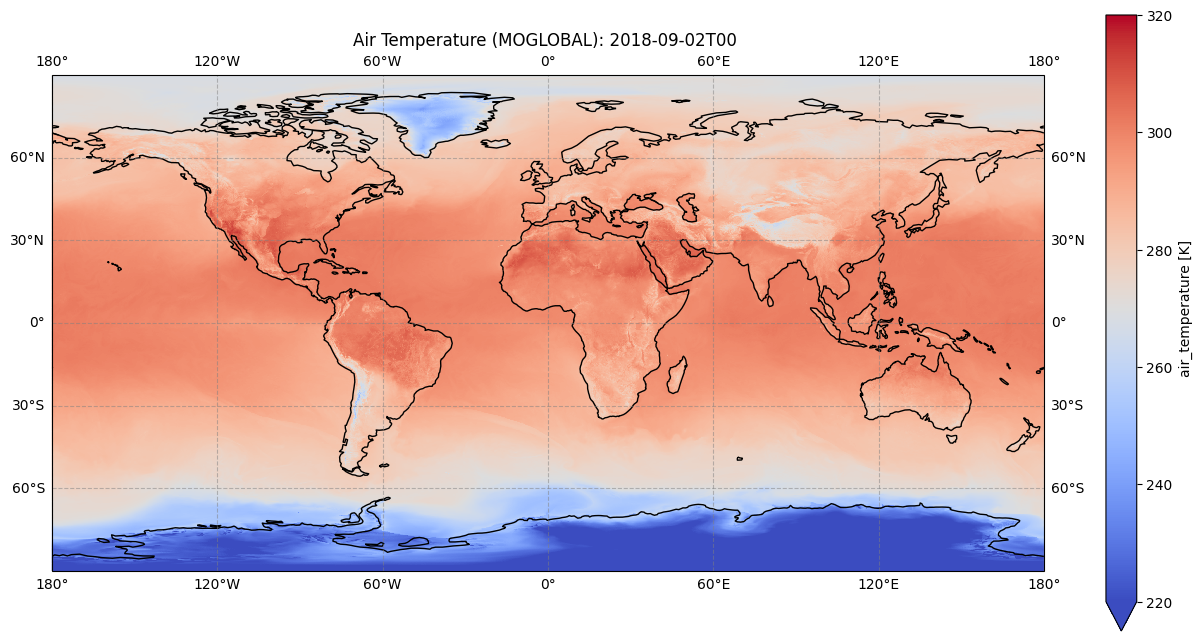

In [14]:
projection = ccrs.PlateCarree()  # Use PlateCarree projection for MOGLOBAL

# Set up the figure and axis
fig1 = plt.figure(figsize=figsize)  
ax1 = fig1.add_subplot(1,1,1,projection=projection) 

# Add Coastlines and gridlines to the map
ax1.coastlines() 
ax1.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)

# Add the MOGLOBAL data using the PyEarthTools .plot() method
moglobal_data.air_temperature.plot(cmap=cmap, vmin=vmin, vmax=vmax,ax=ax1)
ax1.set_title(f"Air Temperature (MOGLOBAL): {doi} ")

## Creating a Pipeline to process data

Fontconfig error: Cannot load default config file: No such file: (null)


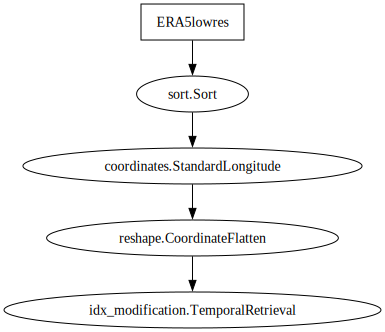

In [15]:
data_preparation = pyearthtools.pipeline.Pipeline(
    
    pyearthtools.data.archive.ERA5lowres(["2m_temperature", "u", "v", "geopotential", "vorticity"]),    # Select data
    pyearthtools.pipeline.operations.xarray.Sort(["t2", "u", "v", "vorticity", "geopotential"]),        # Sort the data
    pyearthtools.data.transforms.coordinates.StandardLongitude(type="0-360"),                           # Convert coordinates to 0-360 longitude        
    pyearthtools.pipeline.operations.xarray.reshape.CoordinateFlatten("level"),                         # Flatten the level coordinate    
    
    pyearthtools.pipeline.modifications.TemporalRetrieval(concat=True, samples=((-1, 1), (6, 1))),      # Retrieve previous/next samples, dt = 1H
    
)

# Display the pipeline
data_preparation

In [16]:
doi = '2015-01-01T00'  
input_and_target_samples = data_preparation[doi]

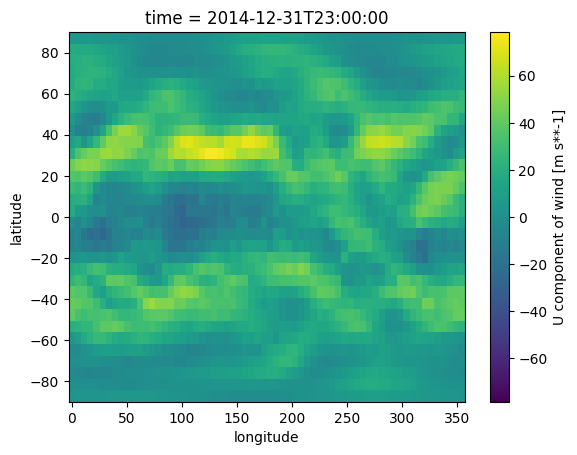

In [17]:
input_and_target_samples[0].u150.plot(cmap='viridis')

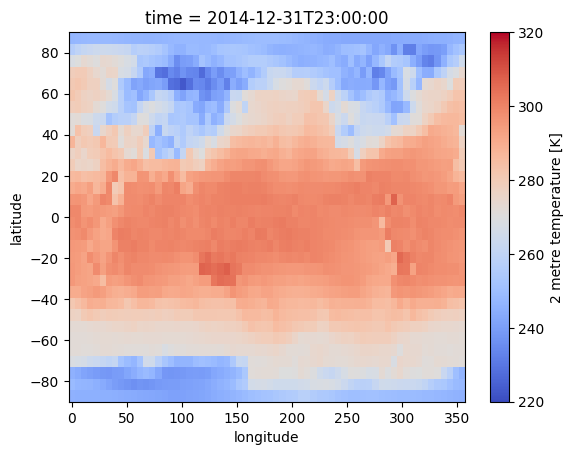

In [18]:
temperature = getattr(input_and_target_samples[0], 't2m')
temperature.plot(cmap=cmap, vmin=vmin, vmax=vmax)